# Sodar qSVM/qKNN Reproduction Walkthrough

This notebook is a compact executable companion to the CLI reproduction. It loads the same JSON notebook configuration, prepares the URL2016 data, explicitly fits representative gate-based and photonic models, then runs the full notebook comparison from the configured model list.

## 1. Paper Claims and Notebook Scope

Sodar et al. compare classical SVM/KNN baselines, gate-based QSVM/QKNN variants, and hybrid quantum-feature SVM/KNN pipelines on encrypted network-traffic datasets. The full repository also adds MerLin photonic reservoir variants and extra validation configs.

The notebook is intentionally smaller than the full curated experiment suite:

- it uses `configs/notebook_url2016.json` as the authoritative configuration;
- it runs explicit-feature models only, because pairwise fidelity-kernel models are implemented but too expensive for an interactive notebook;
- it keeps the same preprocessing and model wrappers used by the CLI runner;
- it reports freshly computed metrics from this notebook execution.

In [11]:
import json
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import auc, roc_curve

paper_root = Path.cwd()
if paper_root.name != "qSVM_qKNN":
    paper_root = (Path.cwd() / "papers" / "qSVM_qKNN").resolve()
else:
    paper_root = paper_root.resolve()
repo_root = paper_root.parents[1]

for path in (repo_root, paper_root):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

from runtime_lib import deep_update
from runtime_lib.config import load_config as runtime_load_config
from runtime_lib.data_paths import ENV_DATA_ROOT, resolve_data_root

from lib.data import load_and_prepare
from lib.models import (
    HybridSklearnModel,
    PhotonicSVMHybridModel,
    make_model,
    make_svc,
)
from lib.training import data_for_model, evaluate_predictions

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 110})

paper_root

PosixPath('/home/vincent/Bureau/Bureau2/workarea/3_Quandela/23_Repro_Docker/1_reproduction_Sodar/0_git_repro_Sodar/papers/qSVM_qKNN')

## 2. Load the Notebook Configuration

The resolved configuration is `defaults.json` overlaid by `notebook_url2016.json`, matching the shared runtime convention. This keeps the notebook tied to the same config files as the CLI runs.

In [12]:
notebook_config_name = "notebook_url2016.json"
configs_dir = paper_root / "configs"

cfg = deep_update(
    runtime_load_config(configs_dir / "defaults.json"),
    runtime_load_config(configs_dir / notebook_config_name),
)
cfg["data_root"] = str(resolve_data_root(cfg.get("data_root"), paper_root))
os.environ.setdefault(ENV_DATA_ROOT, cfg["data_root"])
seed = int(cfg.get("seeds", [42])[0])

important_keys = [
    "dataset",
    "data_source",
    "dataset_file",
    "subset_size",
    "max_test_size",
    "feature_limit",
    "balance_classes",
    "test_size",
    "photonic_n_modes",
    "photonic_n_photons",
    "photonic_computation_space",
    "encoder_batch_size",
    "models",
    "seeds",
]
config_table = pd.DataFrame(
    [{"key": key, "value": cfg.get(key)} for key in important_keys]
)
display(config_table)

,key,value
0,dataset,url2016
1,data_source,csv
2,dataset_file,ISCX-URL-2016/Defacement_Infogain.csv
3,subset_size,0
4,max_test_size,2000
5,feature_limit,None
6,balance_classes,True
7,test_size,0.3
8,photonic_n_modes,None
9,photonic_n_photons,3


## 3. Data Loading and Preprocessing

The same loader prepares three aligned views of the data: standardized classical features, MinMax gate-based inputs, and MerLin-ready photonic inputs. Scalers and encoders are fitted on the training split only and then applied to the test split.

In [13]:
prepared = load_and_prepare(cfg, seed)

preprocessing_summary = pd.DataFrame([
    {"quantity": "source", "value": prepared.source},
    {"quantity": "raw rows", "value": prepared.n_rows_raw},
    {"quantity": "clean/balanced rows before split", "value": prepared.n_rows_clean},
    {"quantity": "train rows", "value": len(prepared.y_train)},
    {"quantity": "test rows", "value": len(prepared.y_test)},
    {"quantity": "raw cleaned features", "value": prepared.n_features_raw},
    {"quantity": "selected input features", "value": len(prepared.feature_names)},
    {"quantity": "selected feature names", "value": ", ".join(prepared.feature_names)},
    {"quantity": "photonic modes", "value": prepared.photonic_preprocessing["n_modes"]},
    {"quantity": "photonic output basis", "value": prepared.photonic_preprocessing.get("output_size")},
    {"quantity": "train class balance", "value": prepared.class_balance},
])
display(preprocessing_summary)

,quantity,value
0,source,/home/vincent/Bureau/Bureau2/workarea/3_Quande...
1,raw rows,15711
2,clean/balanced rows before split,15711
3,train rows,13562
4,test rows,2000
5,raw cleaned features,15
6,selected input features,15
7,selected feature names,"domainlength, argDomanRatio, avgpathtokenlen, ..."
8,photonic modes,15
9,photonic output basis,None


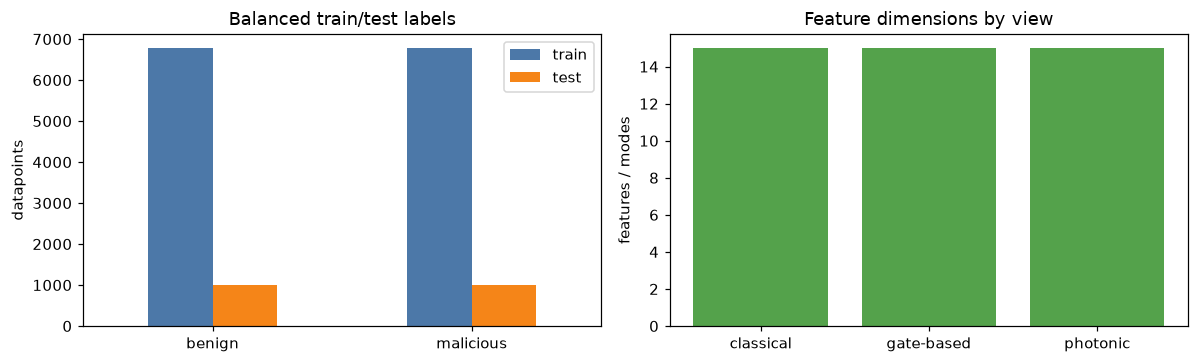

,view,train min,train max,features
0,classical,-2.932,32.696,15
1,gate-based,0.000,1.000,15
2,photonic,0.000,1.000,15


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

train_counts = pd.Series(prepared.y_train).value_counts().sort_index()
test_counts = pd.Series(prepared.y_test).value_counts().sort_index()
counts = pd.DataFrame({"train": train_counts, "test": test_counts}).fillna(0)
counts.index = ["benign" if int(label) == 0 else "malicious" for label in counts.index]
counts.plot(kind="bar", ax=axes[0], color=["#4c78a8", "#f58518"])
axes[0].set_title("Balanced train/test labels")
axes[0].set_ylabel("datapoints")
axes[0].tick_params(axis="x", rotation=0)

view_ranges = pd.DataFrame([
    {"view": "classical", "train min": prepared.X_train_classical.min(), "train max": prepared.X_train_classical.max(), "features": prepared.X_train_classical.shape[1]},
    {"view": "gate-based", "train min": prepared.X_train_quantum.min(), "train max": prepared.X_train_quantum.max(), "features": prepared.X_train_quantum.shape[1]},
    {"view": "photonic", "train min": prepared.X_train_photonic.min(), "train max": prepared.X_train_photonic.max(), "features": prepared.X_train_photonic.shape[1]},
])
axes[1].bar(view_ranges["view"], view_ranges["features"], color="#54a24b")
axes[1].set_title("Feature dimensions by view")
axes[1].set_ylabel("features / modes")
plt.tight_layout()
plt.show()

display(view_ranges.style.format({"train min": "{:.3f}", "train max": "{:.3f}"}))

## 4. Explicit Model Walkthrough

The next cell fits two representative models directly through their Python classes. This is intentionally small so the notebook exposes the model API without hiding everything behind the shared runner.

In [16]:
demo_train_n = len(prepared.y_train)
demo_test_n = len(prepared.y_test)

# These explicit values mirror the resolved notebook configuration.

gate_hybrid_svm = HybridSklearnModel(
    estimator=make_svc(
        kernel="rbf",
        c_value=1.0,
        gamma="scale",
    ),
    encoding="angle",
    device_name="lightning.qubit",
    angle_rotation="Y",
    angle_scale=np.pi,
    hybrid_readout="pauli_z",
    standardize_features=True,
    zz_reps=1,
    zz_entanglement="full",
    zz_alpha=2.0,
    n_jobs=1,
    parallel_chunk_size=None,
    parallel_min_rows=64,
)

photonic_hybrid_svm = PhotonicSVMHybridModel(
    n_modes=None,
    n_photons=3,
    seed=seed,
    device="cpu",
    dtype="float64",
    phase_scale=np.pi,
    batch_size=2048,
    photonic_encoding="angle",
    computation_space="UNBUNCHED",
    standardize_features=True,
    c_value=1.0,
    kernel="rbf",
    gamma="scale",
    feature_cache={},
    n_jobs=1,
    parallel_chunk_size=None,
    parallel_min_rows=64,
)

def fit_predict_demo(label, model, X_train, X_test):
    start = time.perf_counter()
    model.fit(X_train[:demo_train_n], prepared.y_train[:demo_train_n])
    fit_s = time.perf_counter() - start
    start = time.perf_counter()
    y_pred, y_score = model.predict_with_scores(X_test[:demo_test_n])
    predict_s = time.perf_counter() - start
    metrics = evaluate_predictions(
        prepared.y_test[:demo_test_n],
        y_pred,
        y_score=y_score,
        average="binary",
    )
    metadata = model.metadata()
    return {
        "model label": label,
        "class": type(model).__name__,
        "fit_s": fit_s,
        "predict_s": predict_s,
        "accuracy": metrics["accuracy"],
        "f1_score": metrics["f1_score"],
        "roc_auc": metrics.get("roc_auc"),
        "output features": metadata.get("hybrid_output_features") or metadata.get("photonic_output_size"),
        "readout / space": metadata.get("hybrid_readout") or metadata.get("photonic_computation_space"),
    }

walkthrough_rows = [
    fit_predict_demo("gate hybrid SVM angle", gate_hybrid_svm, prepared.X_train_quantum, prepared.X_test_quantum),
    fit_predict_demo("photonic hybrid SVM angle", photonic_hybrid_svm, prepared.X_train_photonic, prepared.X_test_photonic),
]
walkthrough_table = pd.DataFrame(walkthrough_rows)
display(walkthrough_table.style.format({"fit_s": "{:.3f}", "predict_s": "{:.3f}", "accuracy": "{:.4f}", "f1_score": "{:.4f}", "roc_auc": "{:.4f}"}))

,model label,class,fit_s,predict_s,accuracy,f1_score,roc_auc,output features,readout / space
0,gate hybrid SVM angle,HybridSklearnModel,9.899,1.563,0.9680,0.9674,0.9903,15,pauli_z
1,photonic hybrid SVM angle,PhotonicSVMHybridModel,3.738,0.938,0.9820,0.9817,0.9987,455,UNBUNCHED


## 5. Full Notebook Comparison from the JSON Config

The full comparison below loops over every model listed in `configs/notebook_url2016.json`. Each model is instantiated with `make_model(model_name, cfg)`, fitted with `.fit(...)`, and evaluated on the shared test split.

In [17]:
def positive_family(model_name):
    if model_name.startswith("svm_") or "_svm_" in model_name:
        return "svm"
    if model_name.startswith("knn_") or "_knn_" in model_name:
        return "knn"
    return "other"

feature_cache = {}
comparison_rows = []
predictions_by_model = {}

for model_name in cfg["models"]:
    X_train, X_test, y_train, y_test, train_indices, test_indices = data_for_model(model_name, prepared)
    model = make_model(model_name, cfg, feature_cache=feature_cache)

    start = time.perf_counter()
    model.fit(X_train, y_train)
    fit_s = time.perf_counter() - start

    start = time.perf_counter()
    y_pred, y_score = model.predict_with_scores(X_test)
    predict_s = time.perf_counter() - start

    y_train_pred, _ = model.predict_train_with_scores()
    metrics = evaluate_predictions(
        y_test,
        y_pred,
        y_score=y_score,
        average=str(cfg.get("metric_average", "binary")),
    )
    metadata = model.metadata()
    comparison_rows.append({
        "dataset": cfg["dataset"],
        "family": positive_family(model_name),
        "model": model_name,
        "class": type(model).__name__,
        "accuracy": metrics["accuracy"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1_score": metrics["f1_score"],
        "roc_auc": metrics.get("roc_auc", np.nan),
        "fit_s": fit_s,
        "predict_s": predict_s,
        "n_train": len(y_train),
        "n_test": len(y_test),
        "n_features": int(model.n_features_ if model.n_features_ is not None else X_train.shape[1]),
        "n_qubits": model.n_qubits_,
        "output_features": metadata.get("hybrid_output_features") or metadata.get("photonic_output_size"),
    })
    predictions_by_model[model_name] = {
        "y_test": y_test,
        "y_pred": y_pred,
        "y_score": y_score,
        "metadata": metadata,
    }

comparison = pd.DataFrame(comparison_rows)
metric_columns = ["accuracy", "precision", "recall", "f1_score", "roc_auc", "fit_s", "predict_s"]
display(
    comparison[
        ["dataset", "family", "model", "class", "accuracy", "precision", "recall", "f1_score", "roc_auc", "fit_s", "predict_s", "n_train", "n_test", "n_features", "output_features"]
    ].style.format({column: "{:.4f}" for column in metric_columns})
)

,dataset,family,model,class,accuracy,precision,recall,f1_score,roc_auc,fit_s,predict_s,n_train,n_test,n_features,output_features
0,url2016,svm,svm_classical,SklearnModel,0.9705,0.9906,0.9500,0.9699,0.9935,0.5088,0.1650,13562,2000,15,nan
1,url2016,svm,hybrid_svm_angle,HybridSklearnModel,0.9680,0.9865,0.9490,0.9674,0.9903,11.8623,2.0691,13562,2000,15,15.000000
2,url2016,svm,photonic_hybrid_svm_angle,PhotonicSVMHybridModel,0.9820,0.9959,0.9680,0.9817,0.9987,3.8018,0.9610,13562,2000,455,455.000000
3,url2016,svm,photonic_hybrid_svm_amplitude,PhotonicSVMHybridModel,0.9675,0.9855,0.9490,0.9669,0.9949,0.7477,0.3519,13562,2000,20,20.000000
4,url2016,knn,knn_classical,SklearnModel,0.9930,0.9930,0.9930,0.9930,0.9984,0.0117,0.0604,13562,2000,15,nan
5,url2016,knn,hybrid_knn_angle,HybridSklearnModel,0.9915,0.9910,0.9920,0.9915,0.9978,10.9799,1.4522,13562,2000,15,15.000000
6,url2016,knn,photonic_hybrid_knn_angle,PhotonicKNNHybridModel,0.9935,0.9930,0.9940,0.9935,0.9979,1.7857,0.6613,13562,2000,455,455.000000
7,url2016,knn,photonic_hybrid_knn_amplitude,PhotonicKNNHybridModel,0.9940,0.9930,0.9950,0.9940,0.9969,1.4621,0.5603,13562,2000,20,20.000000


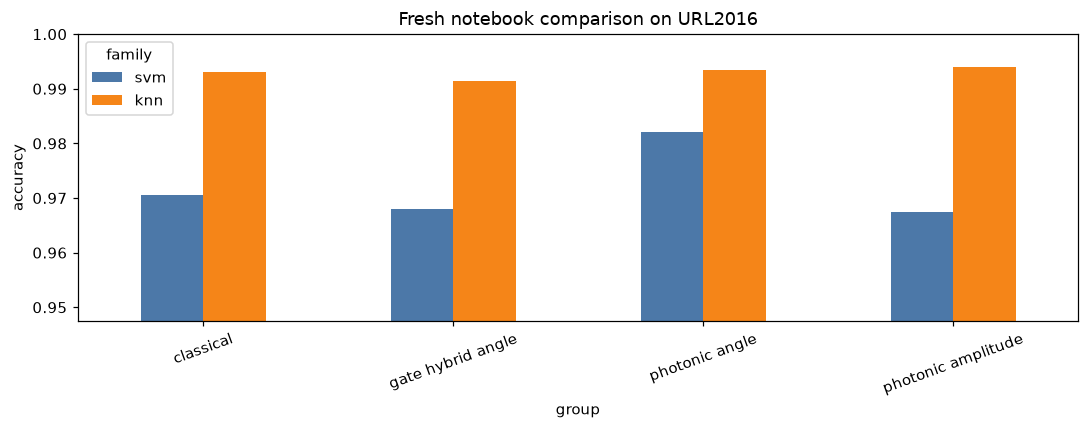

In [18]:
def comparison_group(model_name):
    if model_name.endswith("classical") or model_name in {"svm_classical", "knn_classical"}:
        return "classical"
    if "photonic_hybrid" in model_name and model_name.endswith("_angle"):
        return "photonic angle"
    if "photonic_hybrid" in model_name and model_name.endswith("_amplitude"):
        return "photonic amplitude"
    if model_name.startswith("hybrid_") and model_name.endswith("_angle"):
        return "gate hybrid angle"
    if model_name.startswith("hybrid_") and model_name.endswith("_amplitude"):
        return "gate hybrid amplitude"
    return model_name

plot_df = comparison.copy()
plot_df["group"] = plot_df["model"].map(comparison_group)
pivot = plot_df.pivot_table(index="group", columns="family", values="accuracy", aggfunc="first")
ordered_groups = [group for group in ["classical", "gate hybrid angle", "photonic angle", "photonic amplitude"] if group in pivot.index]
pivot = pivot.loc[ordered_groups]

ax = pivot[[col for col in ["svm", "knn"] if col in pivot.columns]].plot(
    kind="bar",
    figsize=(10, 4),
    color=["#4c78a8", "#f58518"],
)
y_min = max(0.0, float(np.nanmin(pivot.to_numpy())) - 0.02)
ax.set_ylim(y_min, 1.0)
ax.set_ylabel("accuracy")
ax.set_title("Fresh notebook comparison on URL2016")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="family")
plt.tight_layout()
plt.show()

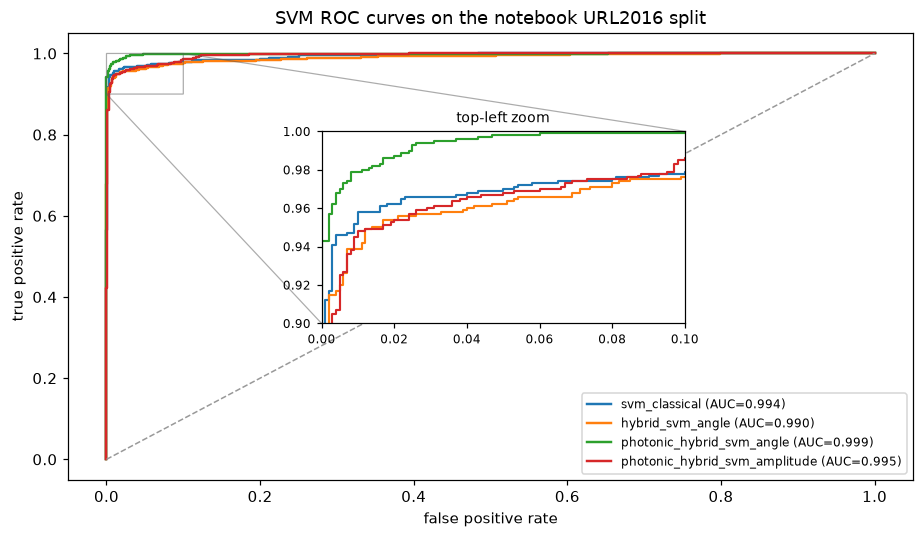

In [26]:
fig, ax = plt.subplots(figsize=(8.5, 5))
zoom_ax = ax.inset_axes([0.30, 0.35, 0.43, 0.43])
svm_subset = comparison[comparison["family"] == "svm"]

for _, row in svm_subset.iterrows():
    payload = predictions_by_model[row["model"]]
    y_score = payload["y_score"]
    if y_score is None:
        continue
    fpr, tpr, _ = roc_curve(payload["y_test"], y_score)
    label = f"{row['model']} (AUC={auc(fpr, tpr):.3f})"
    line = ax.plot(fpr, tpr, label=label, linewidth=1.6)[0]
    zoom_ax.plot(fpr, tpr, linewidth=1.4, color=line.get_color())

ax.plot([0, 1], [0, 1], linestyle="--", color="0.6", linewidth=1)
zoom_ax.plot([0, 1], [0, 1], linestyle="--", color="0.75", linewidth=0.8)
zoom_ax.set_xlim(0.0, 0.10)
zoom_ax.set_ylim(0.90, 1.0)
zoom_ax.set_title("top-left zoom", fontsize=9)
zoom_ax.tick_params(labelsize=8)
ax.indicate_inset_zoom(zoom_ax, edgecolor="0.35", linewidth=0.8)

ax.set_title("SVM ROC curves on the notebook URL2016 split")
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

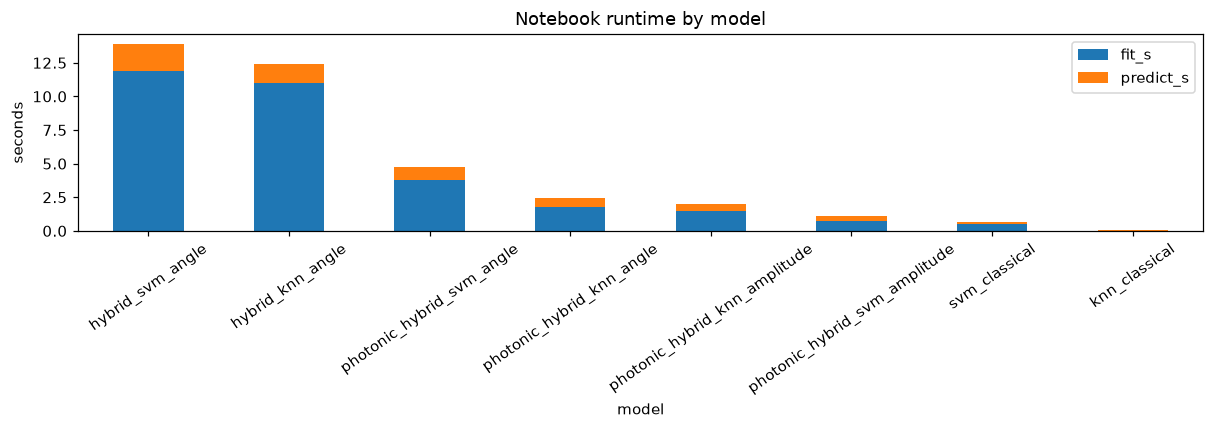

In [27]:
runtime_df = comparison.sort_values("fit_s", ascending=False).copy()
runtime_df["total_s"] = runtime_df["fit_s"] + runtime_df["predict_s"]
ax = runtime_df.plot(
    x="model",
    y=["fit_s", "predict_s"],
    kind="bar",
    stacked=True,
    figsize=(11, 4),
)
ax.set_ylabel("seconds")
ax.set_title("Notebook runtime by model")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

## 6. MerLin Photonic Walkthrough

The photonic models in this notebook use a fixed MerLin reservoir. Angle encoding injects the MinMax-scaled features as phases. Amplitude encoding pads and normalizes the same bounded feature view as a photonic-basis state. Both variants expose explicit probability features to the downstream SVM/KNN.

In [28]:
photonic_rows = comparison[comparison["model"].str.startswith("photonic_")].copy()
photonic_metadata = []
for model_name in photonic_rows["model"]:
    metadata = predictions_by_model[model_name]["metadata"]
    photonic_metadata.append({
        "model": model_name,
        "encoding": metadata.get("photonic_encoding"),
        "computation_space": metadata.get("photonic_computation_space"),
        "n_modes": metadata.get("photonic_n_modes"),
        "n_photons": metadata.get("photonic_n_photons"),
        "input_state": metadata.get("photonic_input_state"),
        "output_size": metadata.get("photonic_output_size"),
        "standardized": metadata.get("photonic_standardize_features"),
    })
photonic_metadata = pd.DataFrame(photonic_metadata)
display(photonic_metadata)

,model,encoding,computation_space,n_modes,n_photons,input_state,output_size,standardized
0,photonic_hybrid_svm_angle,angle,UNBUNCHED,15,3,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1]",455,True
1,photonic_hybrid_svm_amplitude,amplitude,UNBUNCHED,6,3,data_amplitude_statevector,20,True
2,photonic_hybrid_knn_angle,angle,UNBUNCHED,15,3,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1]",455,True
3,photonic_hybrid_knn_amplitude,amplitude,UNBUNCHED,6,3,data_amplitude_statevector,20,True


## 7. Link Back to the Curated Runs

The notebook run above is the fresh executable demonstration. The longer curated result folders contain the broader comparisons, additional datasets, kernel/state-fidelity validation, runtime profiles, and decision-region figures used in the README.

In [29]:
results_dir = paper_root / "results"
results_table = results_dir / "results_table.csv"
if results_table.exists():
    curated = pd.read_csv(results_table)
    url_fast = curated[(curated["experiment"] == "fast_models") & (curated["dataset"] == "url2016")]
    cols = ["experiment", "dataset", "family", "model", "accuracy", "f1_score", "roc_auc", "n_train", "n_test", "n_features"]
    display(url_fast[cols].sort_values(["family", "accuracy"], ascending=[True, False]).head(10).style.format({"accuracy": "{:.4f}", "f1_score": "{:.4f}", "roc_auc": "{:.4f}"}))
else:
    print("Curated results table not found:", results_table)

,experiment,dataset,family,model,accuracy,f1_score,roc_auc,n_train,n_test,n_features


## 8. Interpretation

This notebook confirms the runnable pipeline on a real URL2016 split: one config file defines the dataset, feature preprocessing, model list, and photonic parameters; the code instantiates the high-level wrappers; and each model is fitted and evaluated on the same train/test split.

The notebook does not replace the full curated experiments in `results/`. It deliberately avoids pairwise kernel-trick models so that the run remains interactive. See `README.md` and `METHODS_AND_RESULTS.md` for claim-by-claim outcomes, kernel/state-fidelity validation, IDS2012 runs, and the broader photonic comparison.